In [2]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
from entropy import *

import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.special import jn
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


In [81]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'RP'

BC = 0
prefix = '../results/disorder/PBC/ErgodicNonDiffusive/'
hz = 0

sizes = np.arange(10, 16, 2)

L = 14

dim = int( binom(L, L//2) )

for wx in np.arange(0.2, 1.1, 0.2):
    energy_density =np.arange(0.05, 0.95, 0.02)

    times = np.zeros((400))
    autocorr_q1 = np.zeros((times.size))
    autocorr_q2 = np.zeros((times.size))
    quench_psi_q1 = np.zeros((times.size))
    quench_psi_q2 = np.zeros((times.size))

    omegas = np.zeros((10 * L))
    spec_fun_q1 = np.zeros((omegas.size-1))
    elem_count_q1 = np.zeros((omegas.size-1))
    spec_fun_q2 = np.zeros((omegas.size-1))
    elem_count_q2 = np.zeros((omegas.size-1))

    spec_fun_q1_eps = np.zeros((energy_density.size, omegas.size-1))
    elem_count_q1_eps = np.zeros((energy_density.size, omegas.size-1))
    spec_fun_q2_eps = np.zeros((energy_density.size, omegas.size-1))
    elem_count_q2_eps = np.zeros((energy_density.size, omegas.size-1))
    
    integrated_spectral_fun_q1 = np.zeros((energy_density.size, omegas.size-1))
    integrated_spectral_fun_q2 = np.zeros((energy_density.size, omegas.size-1))
    
    DE_q1 = 0
    DE_q2 = 0
    DE_psi_q1 = 0
    DE_psi_q2 = 0
    
    counter = 0
    for r in range(50 if wx < 0.5 else 25):
        name = prefix + 'realisation=%d/'%r + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                energy_density = np.array(file.get('energy_density'))
                
                times = np.array(file.get('times'))[0]
                autocorr_q1 += np.array(file.get('q=1/autocorrelation'))[0]
                autocorr_q2 += np.array(file.get('q=2/autocorrelation'))[0]
                quench_psi_q1 += np.array(file.get('q=1/quench_psi_q'))[0]
                quench_psi_q2 += np.array(file.get('q=2/quench_psi_q'))[0]
                
                omegas = np.array(file.get('omegas'))[0]
                spec_fun_q1 += np.array(file.get('q=1/spectral_fun_all'))[0]
                elem_count_q1 += np.array(file.get('q=1/element_count_all'))[0]
                spec_fun_q2 += np.array(file.get('q=2/spectral_fun_all'))[0]
                elem_count_q2 += np.array(file.get('q=2/element_count_all'))[0]
                
                spec_fun_q1_eps += np.array(file.get('q=1/spectral_fun'))
                spec_fun_q2_eps += np.array(file.get('q=2/spectral_fun'))
                elem_count_q1_eps += np.array(file.get('q=1/element_count'))
                elem_count_q2_eps += np.array(file.get('q=2/element_count'))
                
                integrated_spectral_fun_q1 += np.array(file.get('q=1/integrated_spectral_fun'))
                integrated_spectral_fun_q2 += np.array(file.get('q=2/integrated_spectral_fun'))
                
                DE_q1 += np.array(file.get('q=1/DE'))[0]
                DE_q2 += np.array(file.get('q=2/DE'))[0]
                DE_psi_q1 += np.array(file.get('q=1/DE_psi'))[0]
                DE_psi_q2 += np.array(file.get('q=2/DE_psi'))[0]
                counter += 1
        else:
            print(name)
    print(wx, counter)
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    with h5py.File(name, 'w') as hf:
        hf.create_dataset('times', times.shape, data = times)
        hf.create_dataset('omegas', omegas.shape, data = omegas)
        hf['q=1/DE'] = DE_q1 / counter
        hf['q=2/DE'] = DE_q2 / counter
        hf['q=1/DE_psi'] = DE_psi_q1 / counter
        hf['q=2/DE_psi'] = DE_psi_q2 / counter
        
        hf.create_dataset('q=1/autocorrelation', autocorr_q1.shape, data = autocorr_q1 / counter)
        hf.create_dataset('q=2/autocorrelation', autocorr_q1.shape, data = autocorr_q2 / counter)
        hf.create_dataset('q=1/quench_psi_q', autocorr_q1.shape, data = quench_psi_q1 / counter)
        hf.create_dataset('q=2/quench_psi_q', autocorr_q1.shape, data = quench_psi_q2 / counter)
        
        hf.create_dataset('q=1/spectral_fun_all', spec_fun_q1.shape, data = spec_fun_q1 / elem_count_q1)
        hf.create_dataset('q=2/spectral_fun_all', spec_fun_q1.shape, data = spec_fun_q2 / elem_count_q2)
        hf.create_dataset('q=1/element_count_all', spec_fun_q1.shape, data = elem_count_q1)
        hf.create_dataset('q=2/element_count_all', spec_fun_q1.shape, data = elem_count_q2)
        
        hf.create_dataset('q=1/integrated_spectral_fun', integrated_spectral_fun_q1.shape, data = integrated_spectral_fun_q1 / counter)
        hf.create_dataset('q=2/integrated_spectral_fun', integrated_spectral_fun_q1.shape, data = integrated_spectral_fun_q1 / counter)
        
        hf.create_dataset('q=1/spectral_fun', spec_fun_q1_eps.shape, data = spec_fun_q1_eps / elem_count_q1_eps)
        hf.create_dataset('q=2/spectral_fun', spec_fun_q1_eps.shape, data = spec_fun_q2_eps / elem_count_q2_eps)
        hf.create_dataset('q=1/element_count', spec_fun_q1_eps.shape, data = elem_count_q1_eps)
        hf.create_dataset('q=2/element_count', spec_fun_q1_eps.shape, data = elem_count_q2_eps)

0.2 50
0.4 50
0.6000000000000001 25


ValueError: operands could not be broadcast together with shapes (400,) (200,) (400,) 

No handles with labels found to put in legend.


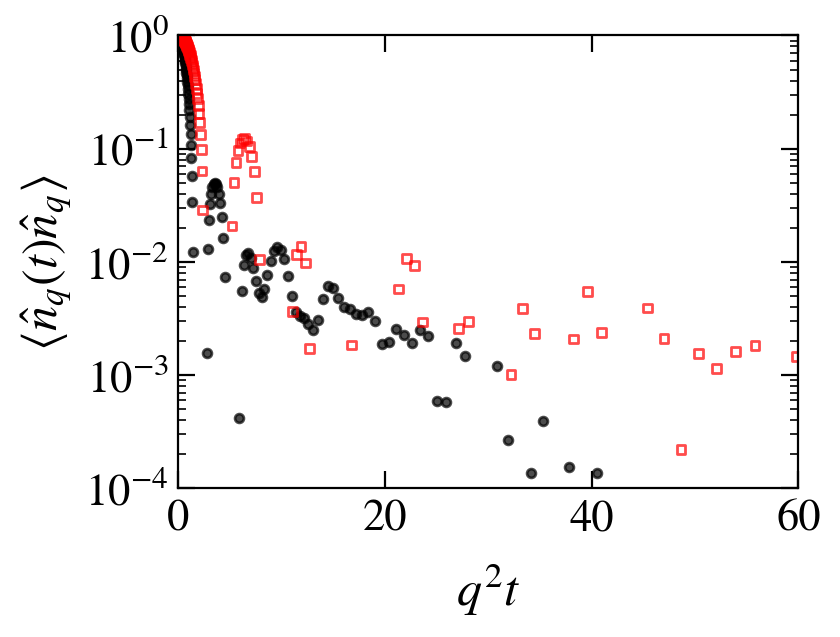

In [126]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)


prefix = '../results/disorder/PBC/ErgodicNonDiffusive/'
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

J=1
delta=0.55
hz=0
wx = 0.2

L = 14
dim = int( binom(L, L//2) )

name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energy_density'))
        # idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
        
        times = np.array(file.get('times'))
        
        cols = ['k', 'red']
        ms = ['o', 's']
        face = ['k', 'None']
        lss = ['-', '--']
        for k in [1,2]:
            q = 2*np.pi * k / L
            autocorr = np.array(file.get('q=%d/autocorrelation'%k))
            DE = np.array(file.get('q=%d/DE'%k))
            autocorr = (autocorr - DE) / (1 - DE)
            axis.scatter(times * q**2, autocorr, color=cols[k-1], alpha=0.7, s=10, marker=ms[k-1], facecolor=face[k-1])
            
            # autocorr = np.array(file.get('q=%d/quench_psi_q'%k))
            # DE = np.array(file.get('q=%d/DE_psi'%k))
            # autocorr = (autocorr - DE) / (1 - DE)
            # axis.plot(times * q**2, autocorr, color=cols[k-1], alpha=0.7, ls=lss[k-1])
else:
    print(name)
    
fig_help.set_plot_elements(axis, ylabel=r"$\langle \hat{n}_q(t)\hat{n}_q\rangle$", xlabel=r"$q^2t$", font_size=16, set_legend=1, xscale='linear', yscale='log')

axis.set_xlim(0, 60)
axis.set_ylim(1e-4, 1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


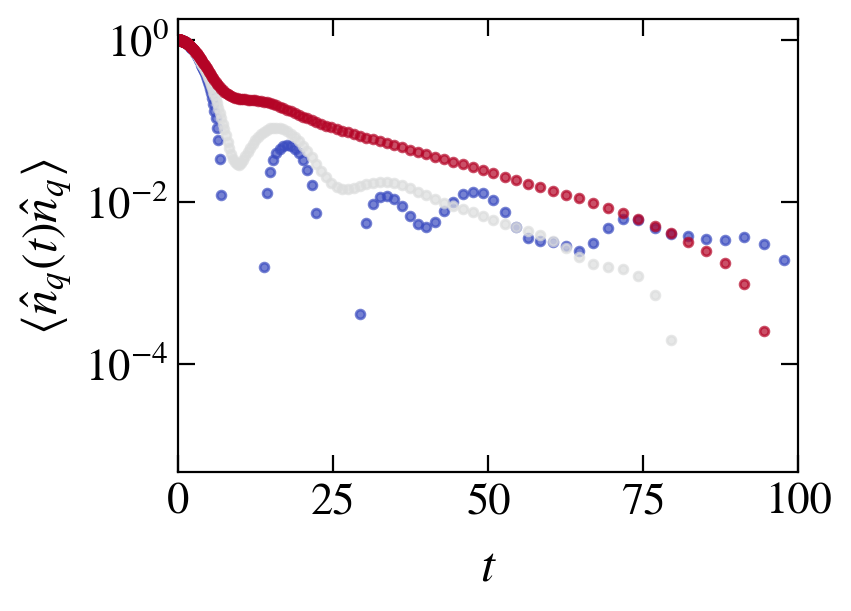

In [92]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)


prefix = '../results/disorder/PBC/ErgodicNonDiffusive/'
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

J=1
delta=0.55
hz=0
wx = 0.2

L = 14
dim = int( binom(L, L//2) )

wx_vals = np.arange(0.2, 0.7, 0.2)
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals)))
s_m.set_array([])
for wx in wx_vals:
    col = s_m.to_rgba(wx)
    name = prefix + info_dis(L=L, J1=J, delta1=delta, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            Ex = np.array(file.get('energy_density'))
            # idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            
            times = np.array(file.get('times'))
            
            autocorr = np.array(file.get('q=1/autocorrelation'))
            DE = np.array(file.get('q=1/DE'))
            autocorr = (autocorr - DE) / (1 - DE)
            
            # autocorr = np.array(file.get('q=1/quench_psi_q'))
            # DE = np.array(file.get('q=1/DE_psi'))
            # autocorr = (autocorr - DE) / (1 - DE)
            
            # autocorr = np.array(file.get('q=2/autocorrelation'))[0]
            axis.scatter(times, autocorr, color=col, alpha=0.7, s=10)
    else:
        print(name)
    
fig_help.set_plot_elements(axis, ylabel=r"$\langle \hat{n}_q(t)\hat{n}_q\rangle$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='linear', yscale='log')

axis.set_xlim(0, 100)
# axis.set_ylim(1e-2, 1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


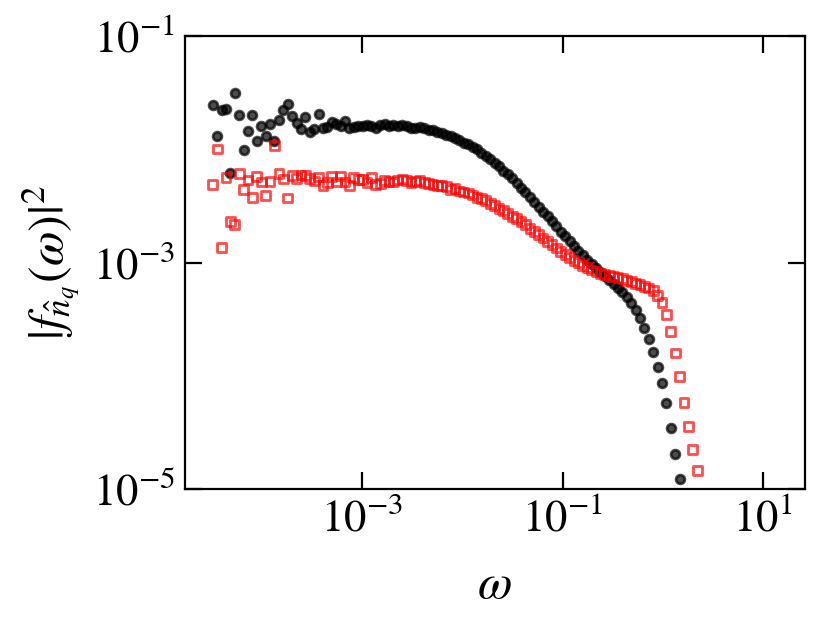

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)



prefix = '../results/disorder/PBC/ErgodicNonDiffusive/'
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)


wx = 1
L = 14
dim = int( binom(L, L//2) )


name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energy_density'))
        # idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
        
        omegas = np.array(file.get('omegas'))[1:]
        
        q = 1
        spec_fun = np.array(file.get('q=1/spectral_fun_all'))
        axis.scatter(omegas, spec_fun, color='k', alpha=0.7, s=10)
        
        q = 2
        spec_fun = np.array(file.get('q=2/spectral_fun_all'))
        axis.scatter(omegas, spec_fun, color='red', alpha=0.7, s=10, marker='s', facecolor='None')
        
else:
    print(name)
    
fig_help.set_plot_elements(axis, ylabel=r"$|f_{ \hat{n}_q}(\omega)|^2$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log')

# axis.set_xlim(0, 10)
axis.set_ylim(1e-5, 1e-1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

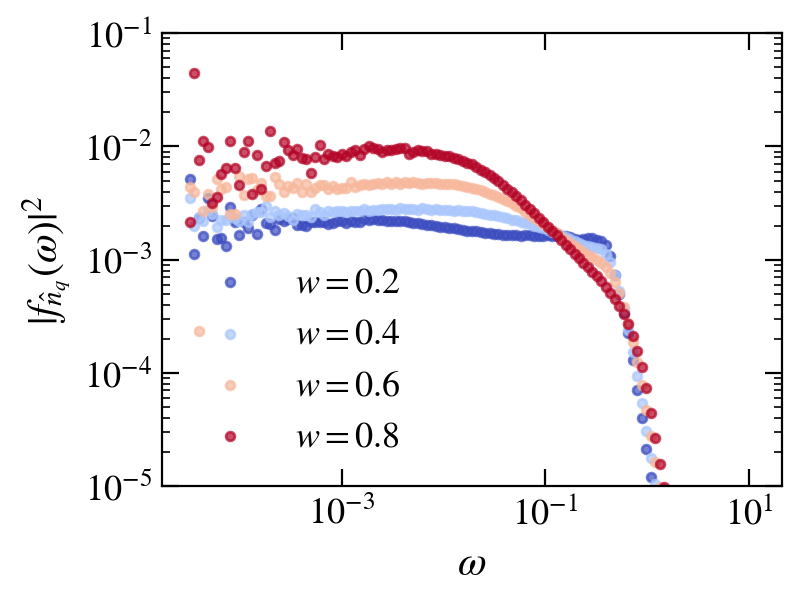

In [112]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)



prefix = '../results/disorder/PBC/ErgodicNonDiffusive/'
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)


wx = 0.6
# wx_vals = [0.1, 0.2, 0.4, 0.5, 0.7, 0.8, 1.0]
wx_vals = [0.2, 0.4, 0.6, 0.8]
s_m = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm=matplotlib.colors.Normalize(
        vmin=min(wx_vals),
        vmax=max(wx_vals)))
s_m.set_array([])

L = 14
dim = int( binom(L, L//2) )
eps = 0.5
Ex =np.arange(0.05, 0.95, 0.02)

for wx in wx_vals:
    col = s_m.to_rgba(wx)
    name = prefix + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            # Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            
            omegas = np.array(file.get('omegas'))[1:]
            
            q = 1
            element_count_all = np.array(file.get('q=%d/element_count'%q))[idx]
            spec_fun = np.array(file.get('q=%d/spectral_fun_all'%q)) #/ element_count_all
            axis.scatter(omegas, spec_fun, color=col, alpha=0.7, s=10, label = r"$w=%g$"%wx)
            
    else:
        print(name)
        
fig_help.set_plot_elements(axis, ylabel=r"$|f_{ \hat{n}_q}(\omega)|^2$", xlabel=r"$\omega$", font_size=13, set_legend=1, xscale='log', yscale='log')

# z = np.logspace(-5, 2, 1000)
# axis.plot(z, 0.0001/z**2, ls='--', color='k')

# axis.plot(z, 0.0001/z, ls='-.', color='green')
# axis.set_xlim(0, 10)
axis.set_ylim(1e-5, 1e-1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)